### **Import Library**

In [42]:
import sys
print(sys.executable)

c:\Users\Raja\AppData\Local\Programs\Python\Python310\python.exe


In [ ]:
# pip install -U ydata-profiling


  Using cached ydata_profiling-4.18.4-py2.py3-none-any.whl.metadata (23 kB)
Using cached ydata_profiling-4.18.4-py2.py3-none-any.whl (400 kB)
  Attempting uninstall: ydata-profiling
    Found existing installation: ydata-profiling 4.18.1
    Uninstalling ydata-profiling-4.18.1:
      Successfully uninstalled ydata-profiling-4.18.1



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
# Jalankan ini jika belum install ydata-profiling:
# !pip install ydata-profiling seaborn matplotlib pandas

import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ydata_profiling import ProfileReport
import warnings

# Mengabaikan warning agar output notebook tetap rapi
warnings.filterwarnings('ignore')

# Set tema visualisasi
sns.set_theme(style="whitegrid")

C:\Users\Raja\AppData\Local\Temp\ipykernel_30476\3877493728.py:8: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


### **Koneksi dan Ekstraksi Data Mentah**

In [2]:
print("Memuat data dari CSV...")
df_raw = pd.read_csv("../data/processed/harga_historis.csv")

# Menampilkan informasi dasar dataframe
print(f"Total Baris: {df_raw.shape[0]}")
print(f"Total Kolom: {df_raw.shape[1]}")
df_raw.info()

# Mengintip 5 baris pertama
display(df_raw.head())

Memuat data dari CSV...
Total Baris: 79808
Total Kolom: 7
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79808 entries, 0 to 79807
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   tanggal_data     79808 non-null  object 
 1   komoditas        79808 non-null  object 
 2   kategori         79808 non-null  object 
 3   harga_per_kg     79808 non-null  float64
 4   satuan_original  79808 non-null  object 
 5   faktor_konversi  79808 non-null  float64
 6   harga_rp         79808 non-null  float64
dtypes: float64(3), object(4)
memory usage: 4.3+ MB


,tanggal_data,komoditas,kategori,harga_per_kg,satuan_original,faktor_konversi,harga_rp
0,2021-05-07,Bawang Putih Sinco/Honan,BAWANG,24600.00,kg,1.000,24600.0
1,2021-05-07,Cabe Merah Besar,CABE,42000.00,kg,1.000,42000.0
2,2021-05-07,Cabe Merah Keriting,CABE,41250.00,kg,1.000,41250.0
3,2021-05-07,Indomie Rasa Kari Ayam,MIE INSTAN,28470.59,Bungkus,0.085,2420.0
4,2021-05-07,Kedelai Lokal,PALAWIJA,11500.00,kg,1.000,11500.0


### **Pandas Profiling (Automated EDA)**

In [46]:
print("Mulai membuat laporan Pandas Profiling. Tunggu sebentar...")

# explorative=True akan melakukan analisis yang lebih mendalam
profile = ProfileReport(df_raw, title="MarketCast Raw Data Profiling", explorative=True)

# Menyimpan hasil ke file HTML
profile.to_file("marketcast_raw_eda_report.html")

print("✅ Laporan HTML berhasil dibuat! Silakan buka 'marketcast_raw_eda_report.html' di browser.")

# Jika ingin menampilkannya langsung di dalam notebook (opsional):
# profile.to_notebook_iframe()

Mulai membuat laporan Pandas Profiling. Tunggu sebentar...


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 7/7 [00:00<00:00, 10.23it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Laporan HTML berhasil dibuat! Silakan buka 'marketcast_raw_eda_report.html' di browser.


### **Manual EDA - Analisis Distribusi**

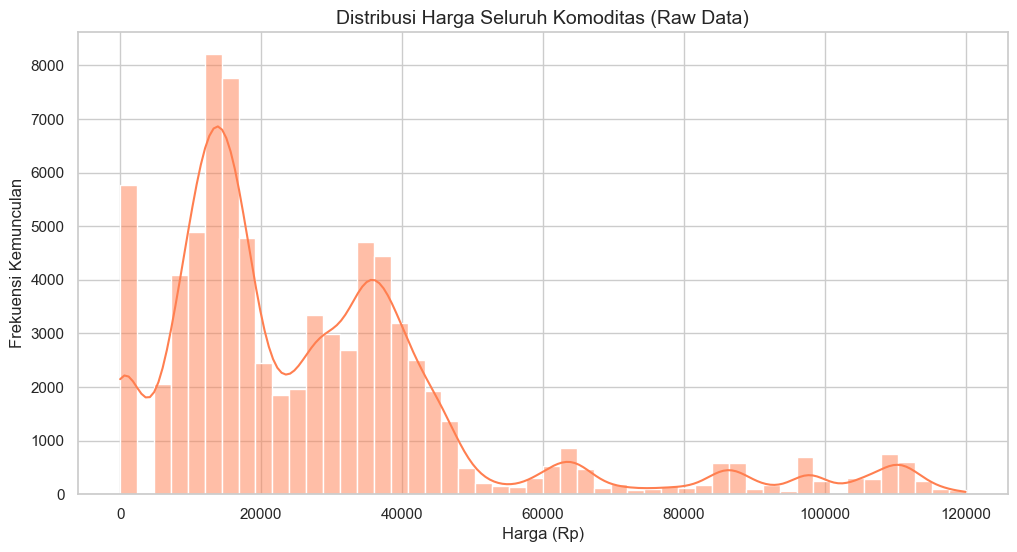

Insight: Terdapat 3916 baris (4.91%) dengan harga Rp 0.
Ini memvalidasi perlunya penghapusan baris harga 0 di tahap Preprocessing.


In [3]:
%matplotlib inline

plt.figure(figsize=(12, 6))

# Kita plotting distribusi harga.
sns.histplot(df_raw['harga_per_kg'], bins=50, kde=True, color='coral')

plt.title('Distribusi Harga Seluruh Komoditas (Raw Data)', fontsize=14)
plt.xlabel('Harga (Rp)', fontsize=12)
plt.ylabel('Frekuensi Kemunculan', fontsize=12)

# Mengatur format angka di sumbu X agar lebih mudah dibaca
plt.ticklabel_format(style='plain', axis='x')
plt.show()

# Mencetak bukti matematis
jumlah_nol = len(df_raw[df_raw['harga_per_kg'] == 0])
persentase_nol = (jumlah_nol / len(df_raw)) * 100
print(f"Insight: Terdapat {jumlah_nol} baris ({persentase_nol:.2f}%) dengan harga Rp 0.")
print("Ini memvalidasi perlunya penghapusan baris harga 0 di tahap Preprocessing.")

### **Manual EDA - Deteksi Outlier (Boxplot)**

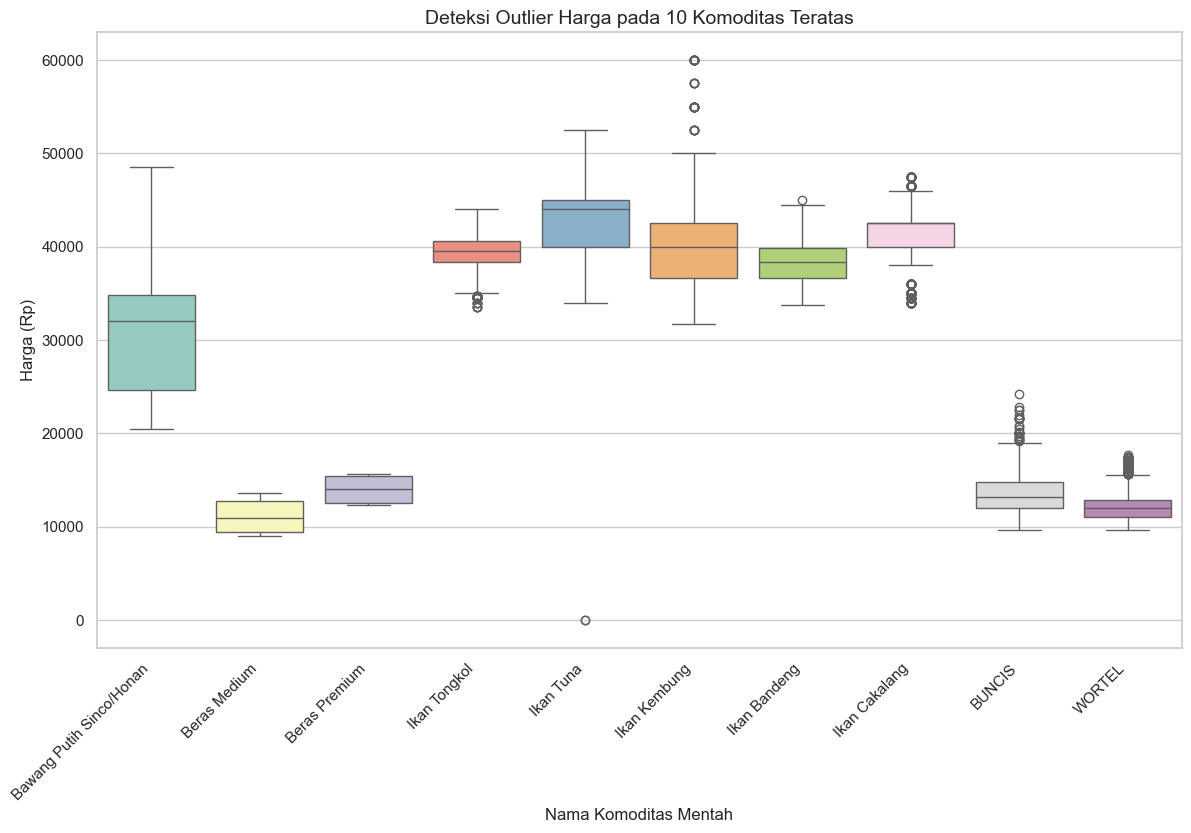

Insight: Perhatikan nama komoditas di sumbu X. Terdapat nama yang diawali dengan tanda hubung atau nomor.
Perhatikan juga titik-titik di luar kotak (outliers) yang menandakan fluktuasi harga ekstrem atau salah ketik dari sumber data.


In [4]:
%matplotlib inline

plt.figure(figsize=(14, 8))

# Mengambil 10 nama komoditas mentah yang paling sering muncul
top_10_komoditas = df_raw['komoditas'].value_counts().nlargest(10).index
df_sampel = df_raw[df_raw['komoditas'].isin(top_10_komoditas)]

# Membuat Boxplot
sns.boxplot(data=df_sampel, x='komoditas', y='harga_rp', palette='Set3')

plt.title('Deteksi Outlier Harga pada 10 Komoditas Teratas', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Nama Komoditas Mentah', fontsize=12)
plt.ylabel('Harga (Rp)', fontsize=12)
plt.show()

print("Insight: Perhatikan nama komoditas di sumbu X. Terdapat nama yang diawali dengan tanda hubung atau nomor.")
print("Perhatikan juga titik-titik di luar kotak (outliers) yang menandakan fluktuasi harga ekstrem atau salah ketik dari sumber data.")

### **Manual EDA - Pengecekan Duplikasi**

In [5]:
%matplotlib inline

# 1. Cek duplikasi baris secara keseluruhan
total_duplikat = df_raw.duplicated().sum()
print(f"Total baris duplikat persis: {total_duplikat}")

# 2. Cek konsistensi tanggal
df_raw['tanggal_data'] = pd.to_datetime(df_raw['tanggal_data'], errors='coerce')
tanggal_awal = df_raw['tanggal_data'].min().date()
tanggal_akhir = df_raw['tanggal_data'].max().date()

print(f"\nRentang Data Historis: {tanggal_awal} hingga {tanggal_akhir}")

Total baris duplikat persis: 0

Rentang Data Historis: 2021-05-07 hingga 2026-06-06


### **Manual EDA - Pengecekan Korelasi/Hubungan Antar Fitur**

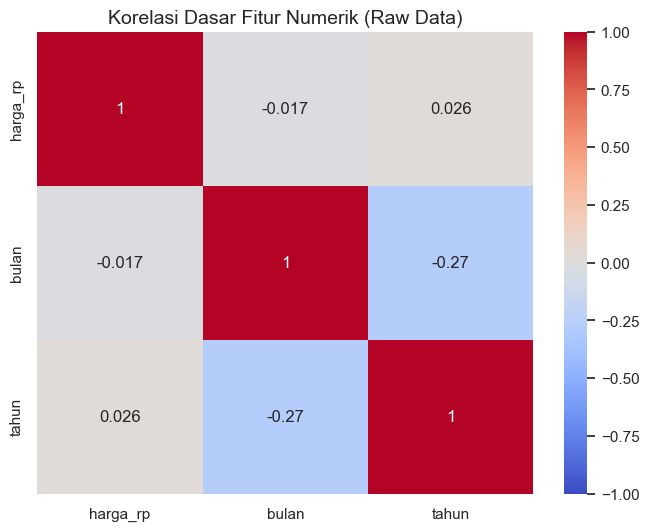

In [6]:
# 1. Cek korelasi dasar antar kolom numerik (Meski di raw data hanya ada harga_rp)
# Kita tambahkan fitur waktu sementara untuk melihat heatmaps
df_raw['bulan'] = pd.to_datetime(df_raw['tanggal_data']).dt.month
df_raw['tahun'] = pd.to_datetime(df_raw['tanggal_data']).dt.year

plt.figure(figsize=(8, 6))
sns.heatmap(df_raw[['harga_rp', 'bulan', 'tahun']].corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Korelasi Dasar Fitur Numerik (Raw Data)', fontsize=14)
plt.show()

### **Manual EDA - Coverage Check per Komoditas**
Memeriksa seberapa lengkap data tiap komoditas: apakah ada komoditas yang datanya bolong-bolong atau hanya hadir di sebagian periode.

Total rentang hari dalam dataset: 1856 hari
Total sub-komoditas: 43
Komoditas dengan coverage < 80%: 4 item
komoditas
Susu Bubuk Merk Indomilk (Instant)    26.293103
Minyak Goreng Kemasan Sederhana       39.439655
Susu Bubuk Merk Bendera (Instant)     52.370690
Minyak Goreng MINYAKITA               72.467672
dtype: float64


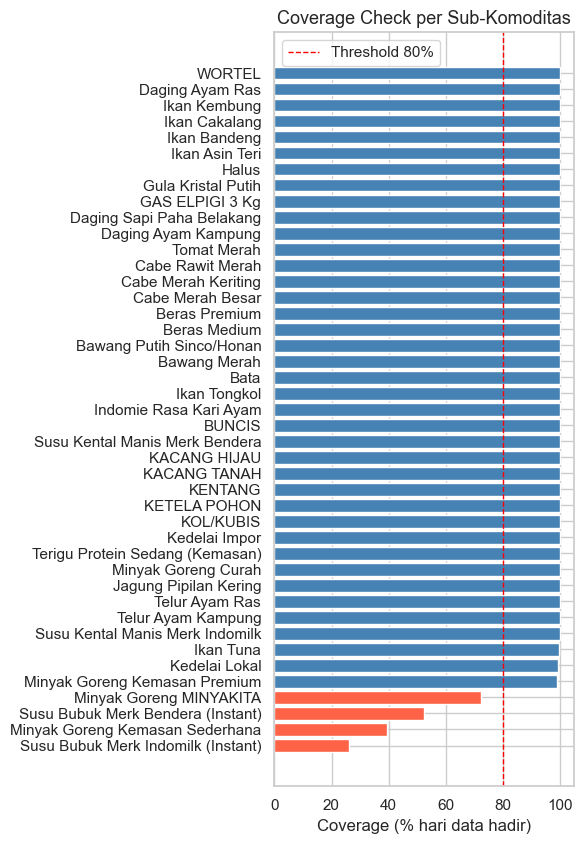

Insight: Komoditas berwarna merah memiliki banyak missing value dan perlu
penanganan khusus di tahap preprocessing (interpolasi / drop).


In [7]:
%matplotlib inline
import numpy as np

# Siapkan sub-komoditas saja (strip header kategori seperti 'BERAS', 'GULA')
sub_komoditas = df_raw['komoditas'].unique().tolist()

df_raw['tanggal_data'] = pd.to_datetime(df_raw['tanggal_data'], errors='coerce')
df_valid = df_raw[df_raw['harga_rp'] > 0].copy()

# Pivot: baris = tanggal, kolom = komoditas, nilai = rata-rata harga
pivot_df = (
    df_valid[df_valid['komoditas'].isin(sub_komoditas)]
    .groupby(['tanggal_data', 'komoditas'])['harga_rp']
    .mean()
    .unstack()
)

# Hitung coverage (% hari data tersedia) per komoditas
total_hari = len(pivot_df)
coverage_pct = (pivot_df.notna().sum() / total_hari * 100).sort_values(ascending=True)

print(f"Total rentang hari dalam dataset: {total_hari} hari")
print(f"Total sub-komoditas: {len(sub_komoditas)}")

# Tampilkan komoditas dengan coverage rendah (<80%)
low_coverage = coverage_pct[coverage_pct < 80]
print(f"Komoditas dengan coverage < 80%: {len(low_coverage)} item")
print(low_coverage)

# Bar chart coverage
fig, ax = plt.subplots(figsize=(6, max(8, len(sub_komoditas) * 0.2)))
ax.barh(coverage_pct.index, coverage_pct.values, color=[
    'tomato' if v < 80 else 'steelblue' for v in coverage_pct.values
])
ax.axvline(80, color='red', linestyle='--', linewidth=1, label='Threshold 80%')
ax.set_xlabel('Coverage (% hari data hadir)')
ax.set_title('Coverage Check per Sub-Komoditas', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

print("Insight: Komoditas berwarna merah memiliki banyak missing value dan perlu")
print("penanganan khusus di tahap preprocessing (interpolasi / drop).")


### **Manual EDA - Tren Time Series Komoditas Pangan Utama**
Visualisasi pergerakan harga dari waktu ke waktu untuk komoditas pangan strategis.

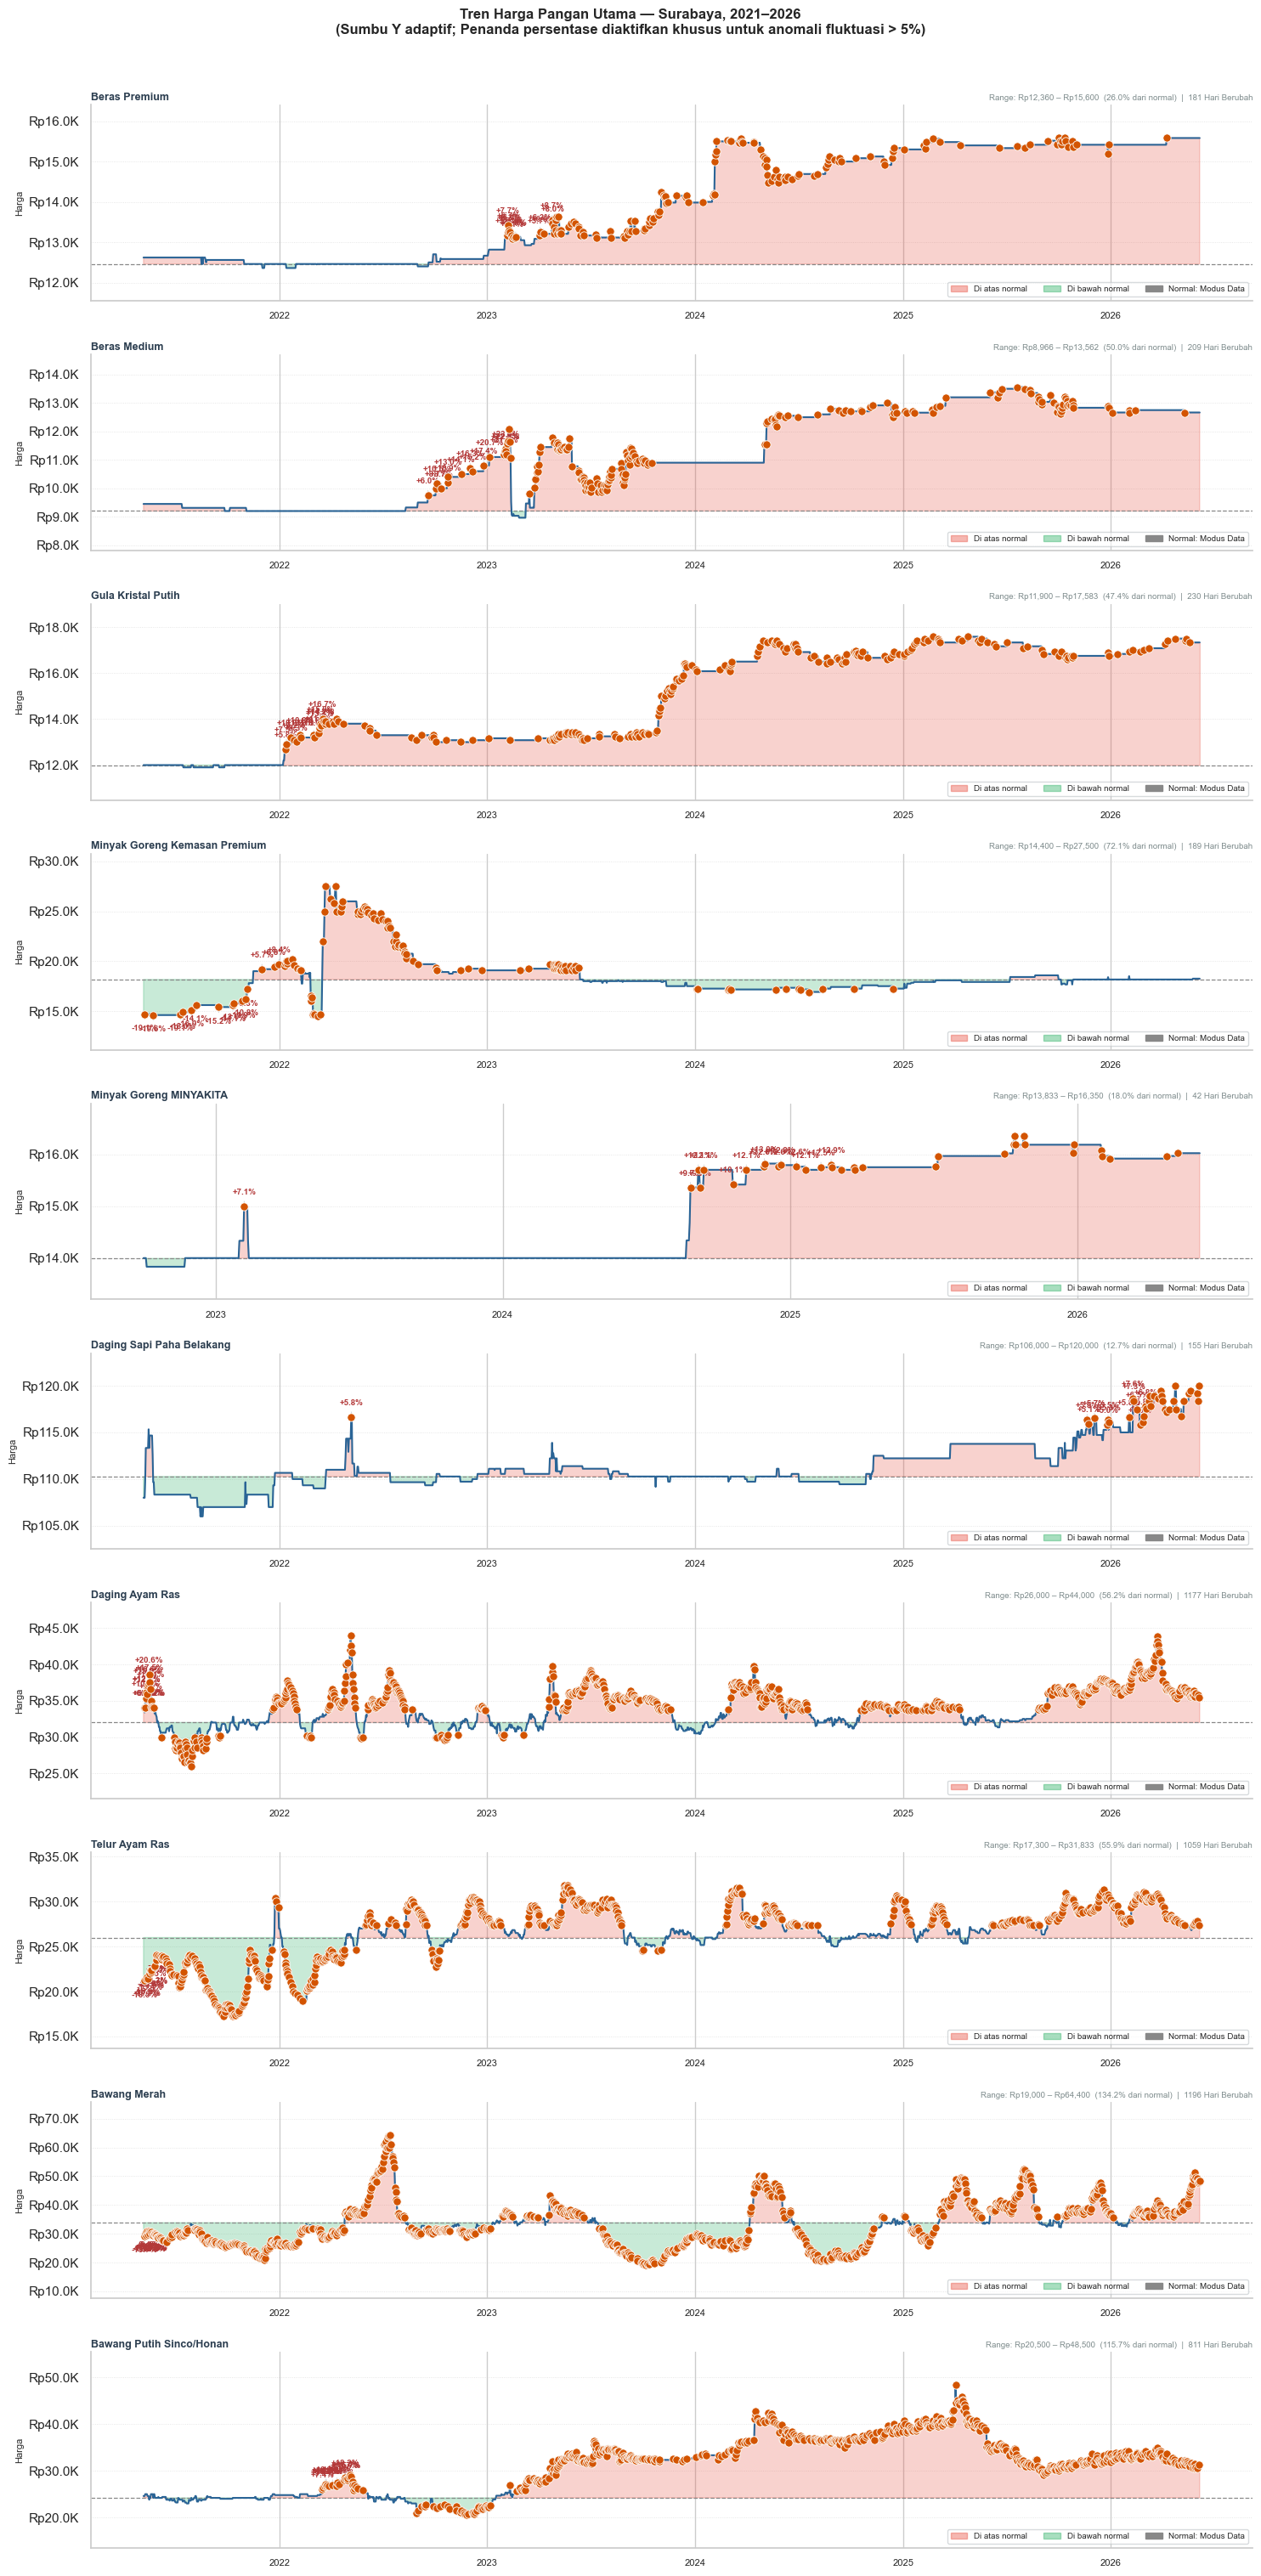

In [8]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt  # Pastikan plt terimport
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches

# ── Konfigurasi ───────────────────────────────────────────────────────────────
PANGAN_UTAMA = [
    'Beras Premium', 'Beras Medium',
    'Gula Kristal Putih',
    'Minyak Goreng Kemasan Premium', 'Minyak Goreng MINYAKITA',
    'Daging Sapi Paha Belakang', 'Daging Ayam Ras',
    'Telur Ayam Ras',
    'Bawang Merah', 'Bawang Putih Sinco/Honan',
]
komod_plot = [k for k in PANGAN_UTAMA if k in pivot_df.columns]
short_label = lambda k: k

# ── Setup figure ──────────────────────────────────────────────────────────────
n = len(komod_plot)
fig, axes = plt.subplots(n, 1, figsize=(15, n * 3.0), sharex=False)
if n == 1:
    axes = [axes]

for ax, komod in zip(axes, komod_plot):
    series   = pivot_df[komod].dropna()
    mode_val = float(series.mode().iloc[0])   # harga dominan/konstan
    s_min    = series.min()
    s_max    = series.max()
    rng_pct  = (s_max - s_min) / (mode_val + 1e-9) * 100

    # Deteksi titik perubahan harian
    diff        = series.diff().fillna(0)
    changed_idx = series.index[diff != 0]
    n_changes   = len(changed_idx)

    # ── Plot garis utama ──────────────────────────────────────────────────────
    ax.plot(series.index, series.values,
            linewidth=1.5, color='#2a6496', zorder=3)

    # ── Garis referensi nilai konstan dominan ────────────────────────────────
    ax.axhline(mode_val, color='#888888', linestyle='--',
               linewidth=0.9, zorder=2)

    # ── Area fill: merah = naik dari normal, hijau = turun dari normal ────────
    ax.fill_between(
        series.index, series.values, mode_val,
        where=(series.values > mode_val),
        alpha=0.25, color='#e74c3c', interpolate=True, zorder=1
    )
    ax.fill_between(
        series.index, series.values, mode_val,
        where=(series.values < mode_val),
        alpha=0.25, color='#27ae60', interpolate=True, zorder=1
    )

    # ── OPTIMASI: Marker & Anotasi Hanya untuk Fluktuasi Ekstrem (> 5%) ─────
    if n_changes > 0:
        changed_vals = series.loc[changed_idx]
        
        # Hitung deviasi semua titik perubahan terhadap harga normal
        deviations = (changed_vals - mode_val) / mode_val * 100
        
        # Saring hanya yang perubahannya ekstrem (> 5% atau < -5%) agar Matplotlib tidak overload
        ekstrem_idx = deviations[deviations.abs() > 5.0].index
        
        if len(ekstrem_idx) > 0:
            ekstrem_vals = series.loc[ekstrem_idx]
            
            # Gambar titik scatter hanya pada fluktuasi besar
            ax.scatter(ekstrem_idx, ekstrem_vals,
                       s=45, color='#d35400', zorder=5,
                       linewidths=0.6, edgecolors='white')

            # Batasi maksimal memberi anotasi teks teks agar tidak bertumpuk berantakan
            for dt, val in ekstrem_vals.head(15).items():
                delta_pct = (val - mode_val) / mode_val * 100
                sign = '+' if delta_pct > 0 else ''
                ax.annotate(
                    f'{sign}{delta_pct:.1f}%',
                    xy=(dt, val),
                    xytext=(0, 10 if val >= mode_val else -14),
                    textcoords='offset points',
                    fontsize=7, ha='center', color='#b33939',
                    fontweight='bold',
                    arrowprops=dict(arrowstyle='-', color='#bdc3c7', lw=0.5)
                )

    # ── Zoom sumbu Y adaptif ──────────────────────────────────────────────────
    padding = max((s_max - s_min) * 0.25, mode_val * 0.02)
    ax.set_ylim(s_min - padding, s_max + padding)
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'Rp{x/1000:.1f}K')
    )
    ax.set_ylabel('Harga', fontsize=8)

    # ── Sumbu X per subplot ───────────────────────────────────────────────────
    ax.xaxis.set_major_locator(plt.matplotlib.dates.YearLocator())
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y'))
    ax.tick_params(axis='x', labelsize=8)

    # ── Title kiri (nama komoditas) + kanan (badge info) ─────────────────────
    ax.set_title(short_label(komod),
                 fontsize=9, loc='left', pad=4,
                 fontweight='bold', color='#2c3e50')
    ax.set_title(
        f'Range: Rp{s_min:,.0f} – Rp{s_max:,.0f}  '
        f'({rng_pct:.1f}% dari normal)  |  {n_changes} Hari Berubah',
        fontsize=7, loc='right', pad=4, color='#7f8c8d'
    )

    # ── Legend ────────────────────────────────────────────────────────────────
    ax.legend(
        handles=[
            mpatches.Patch(color='#e74c3c', alpha=0.4, label='Di atas normal'),
            mpatches.Patch(color='#27ae60', alpha=0.4, label='Di bawah normal'),
            mpatches.Patch(color='#888888', label=f'Normal: Modus Data')
        ],
        fontsize=7, loc='lower right', ncol=3,
        framealpha=0.6, edgecolor='#bdc3c7'
    )
    ax.grid(axis='y', linestyle=':', linewidth=0.6, alpha=0.6)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle(
    'Tren Harga Pangan Utama — Surabaya, 2021–2026\n'
    '(Sumbu Y adaptif; Penanda persentase diaktifkan khusus untuk anomali fluktuasi > 5%)',
    fontsize=12, y=1.01, fontweight='bold'
)
plt.tight_layout(h_pad=1.5)
plt.show()

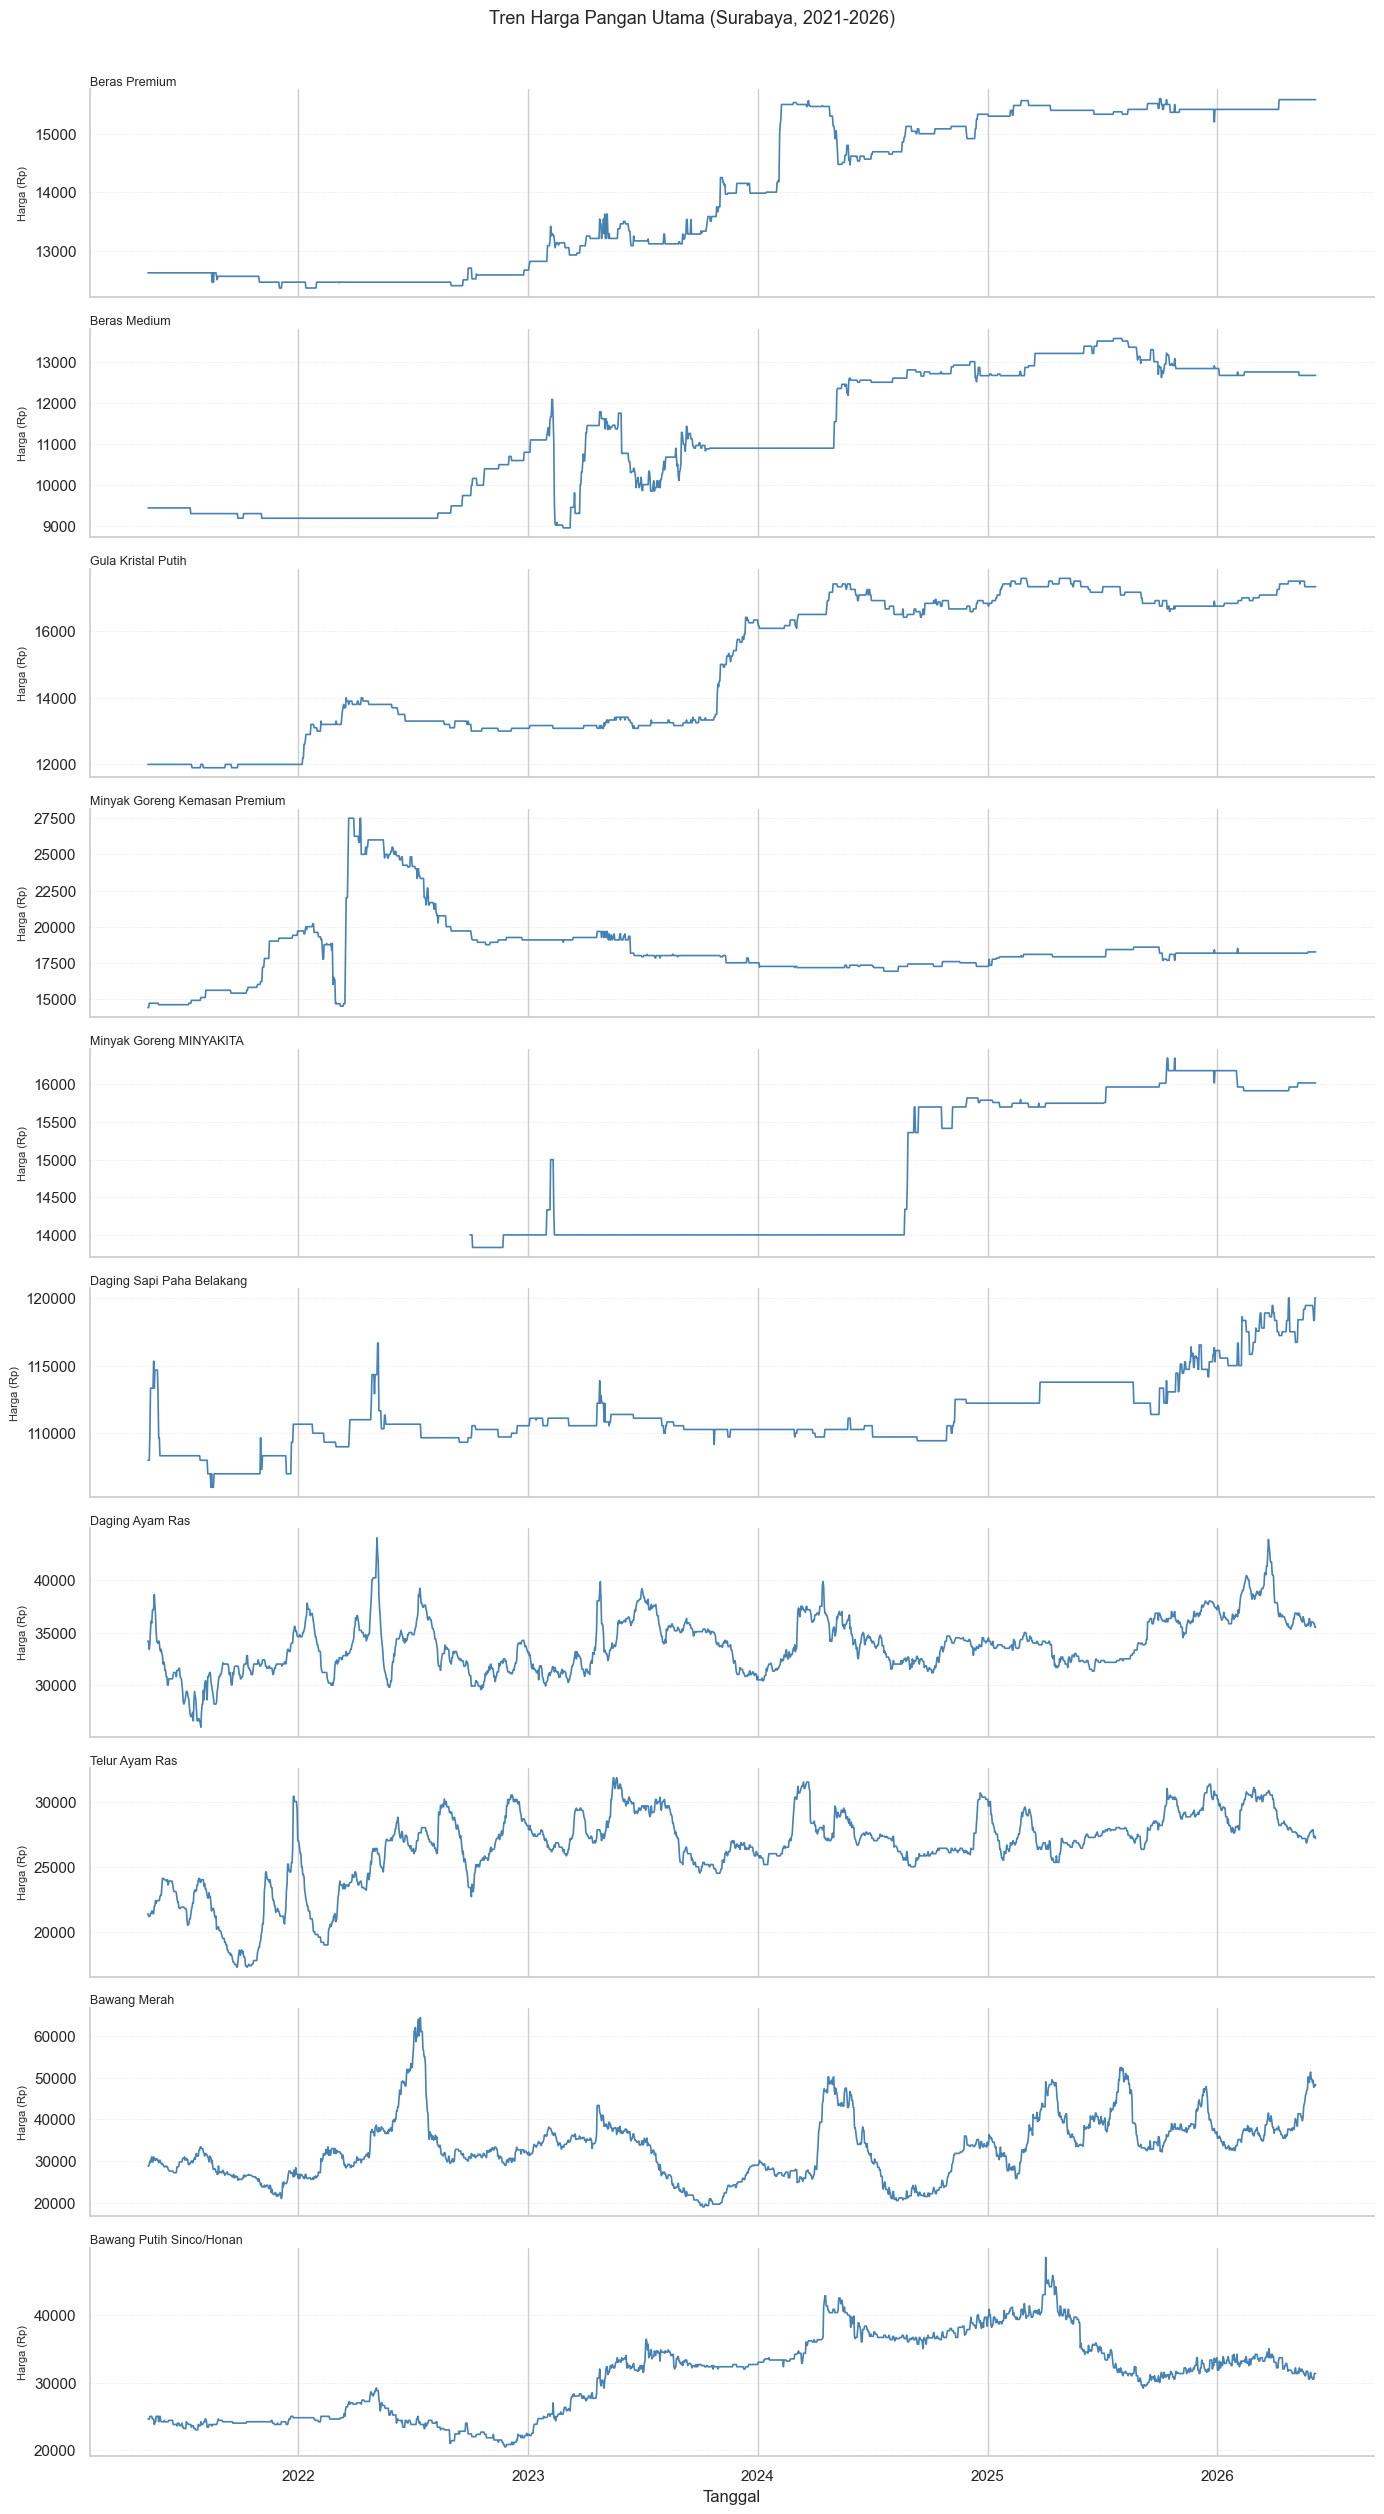


Insight EDA:
- Amati lonjakan atau penurunan tajam yang berkaitan dengan
  event tertentu (Ramadan, Idulfitri, kebijakan HET pemerintah, guncangan pasokan global).
- Jika grafik terlihat datar/flat dalam rentang waktu yang sangat panjang,
  hal ini mengindikasikan adanya isu data tidak diperbarui oleh petugas lapangan portal sumber.


In [9]:
%matplotlib inline

# Daftar komoditas pangan utama yang paling relevan
PANGAN_UTAMA = [
    'Beras Premium', 'Beras Medium',
    'Gula Kristal Putih',
    'Minyak Goreng Kemasan Premium', 'Minyak Goreng MINYAKITA',
    'Daging Sapi Paha Belakang', 'Daging Ayam Ras',
    'Telur Ayam Ras',
    'Bawang Merah', 'Bawang Putih Sinco/Honan',
]

# Filter hanya komoditas yang tersedia di pivot_df
komod_plot = [k for k in PANGAN_UTAMA if k in pivot_df.columns]

fig, axes = plt.subplots(len(komod_plot), 1, figsize=(14, len(komod_plot) * 2.5), sharex=True)
if len(komod_plot) == 1:
    axes = [axes]

for ax, komod in zip(axes, komod_plot):
    series = pivot_df[komod].dropna()
    ax.plot(series.index, series.values, linewidth=1.2, color='steelblue')
    ax.set_ylabel('Harga (Rp)', fontsize=8)
    ax.set_title(komod, fontsize=9, loc='left', pad=3)
    ax.ticklabel_format(style='plain', axis='y')
    ax.grid(axis='y', linestyle=':', linewidth=0.5, alpha=0.7)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Tren Harga Pangan Utama (Surabaya, 2021-2026)', fontsize=13, y=1.005)
plt.xlabel('Tanggal')
plt.tight_layout()
plt.show()

print("\nInsight EDA:")
print("- Amati lonjakan atau penurunan tajam yang berkaitan dengan")
print("  event tertentu (Ramadan, Idulfitri, kebijakan HET pemerintah, guncangan pasokan global).")
print("- Jika grafik terlihat datar/flat dalam rentang waktu yang sangat panjang,")
print("  hal ini mengindikasikan adanya isu data tidak diperbarui oleh petugas lapangan portal sumber.")

### **Manual EDA - Seasonality Bulanan**
Analisis rata-rata harga per bulan untuk mendeteksi pola musiman yang berulang setiap tahun.

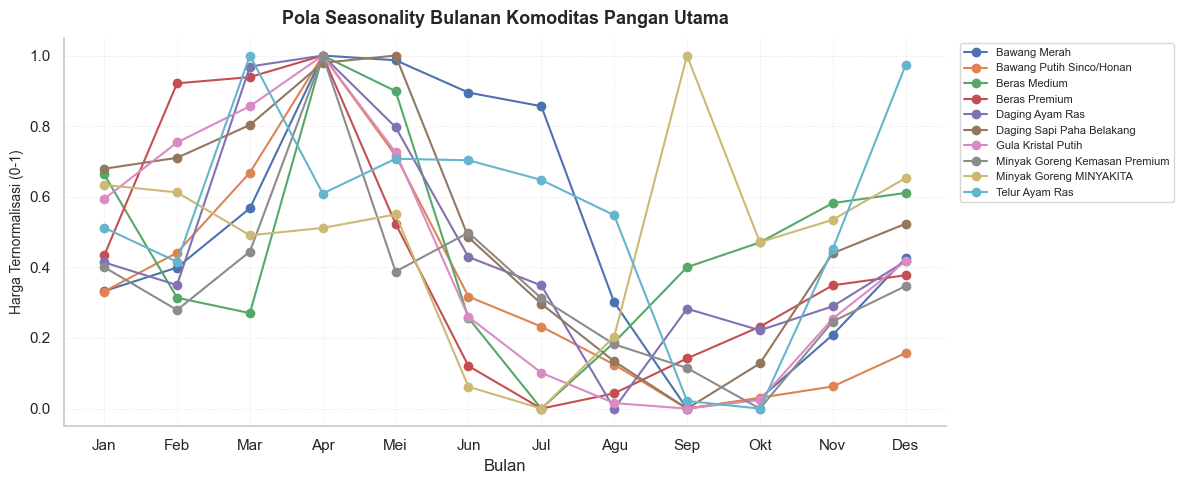


 Validasi Konteks Riil Kebijakan & Hari Besar:
1. Amati pergeseran harga pada rentang Maret-April.
   Mengingat Ramadan dan Idulfitri di rentang tahun 2021-2026 bergeser di bulan-bulan tersebut,
   lonjakan nilai normalisasi mendekati 1.0 mengonfirmasi adanya guncangan permintaan (*demand shock*).
2. Lonjakan di bulan Desember mengonfirmasi pola musiman dampak Hari Raya Natal dan Libur Tahun Baru.


In [ ]:
%matplotlib inline

df_valid['bulan'] = df_valid['tanggal_data'].dt.month
df_valid['tahun']  = df_valid['tanggal_data'].dt.year

# Hanya sub-komoditas pangan utama
df_seasonal = df_valid[df_valid['komoditas'].isin(komod_plot)].copy()

# Rata-rata harga per bulan per komoditas (gabung semua tahun)
seasonal = (
    df_seasonal.groupby(['komoditas', 'bulan'])['harga_rp']
    .mean()
    .unstack(level=0)  # kolom = komoditas, baris = bulan
)

# Normalisasi agar tiap komoditas bisa dibandingkan (scale 0-1)
denom = seasonal.max() - seasonal.min()

# Jika ada selisih yang bernilai 0, ganti dengan 1 agar tidak crash saat membagi
denom = denom.replace(0, 1)

seasonal_norm = (seasonal - seasonal.min()) / denom

bulan_label = ['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agu','Sep','Okt','Nov','Des']

fig, ax = plt.subplots(figsize=(12, 5))
for komod in seasonal_norm.columns:
    ax.plot(range(1, 13), seasonal_norm[komod].values, marker='o', label=komod, linewidth=1.5)

ax.set_xticks(range(1, 13))
ax.set_xticklabels(bulan_label)
ax.set_xlabel('Bulan')
ax.set_ylabel('Harga Ternormalisasi (0-1)', fontsize=10)
ax.set_title('Pola Seasonality Bulanan Komoditas Pangan Utama', fontsize=13, fontweight='bold', pad=10)
ax.grid(axis='both', linestyle=':', linewidth=0.5, alpha=0.7)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8, framealpha=0.8)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

print("\n Validasi Konteks Riil Kebijakan & Hari Besar:")
print("1. Amati pergeseran harga pada rentang Maret-April.")
print("   Mengingat Ramadan dan Idulfitri di rentang tahun 2021-2026 bergeser di bulan-bulan tersebut,")
print("   lonjakan nilai normalisasi mendekati 1.0 mengonfirmasi adanya guncangan permintaan (*demand shock*).")
print("2. Lonjakan di bulan Desember mengonfirmasi pola musiman dampak Hari Raya Natal dan Libur Tahun Baru.")

### **Manual EDA - Volatilitas (Coefficient of Variation)**

=== Coefficient of Variation (CV) per Komoditas ===
Komoditas                                   Mean        Std    CV (%)   Rank
Bawang Merah                              33,013    7,589.2    22.99%  ████████████████████
Bawang Putih Sinco/Honan                  30,879    5,889.5    19.07%  ████████████████
Beras Medium                              11,196    1,540.6    13.76%  ███████████
Gula Kristal Putih                        14,941    2,050.6    13.72%  ███████████
Minyak Goreng Kemasan Premium             18,313    2,138.9    11.68%  ██████████
Telur Ayam Ras                            26,537    2,932.4    11.05%  █████████
Beras Premium                             13,974    1,274.9     9.12%  ███████
Daging Ayam Ras                           33,838    2,560.7     7.57%  ██████
Minyak Goreng MINYAKITA                   14,905      949.6     6.37%  █████
Daging Sapi Paha Belakang                111,340    2,629.7     2.36%  ██


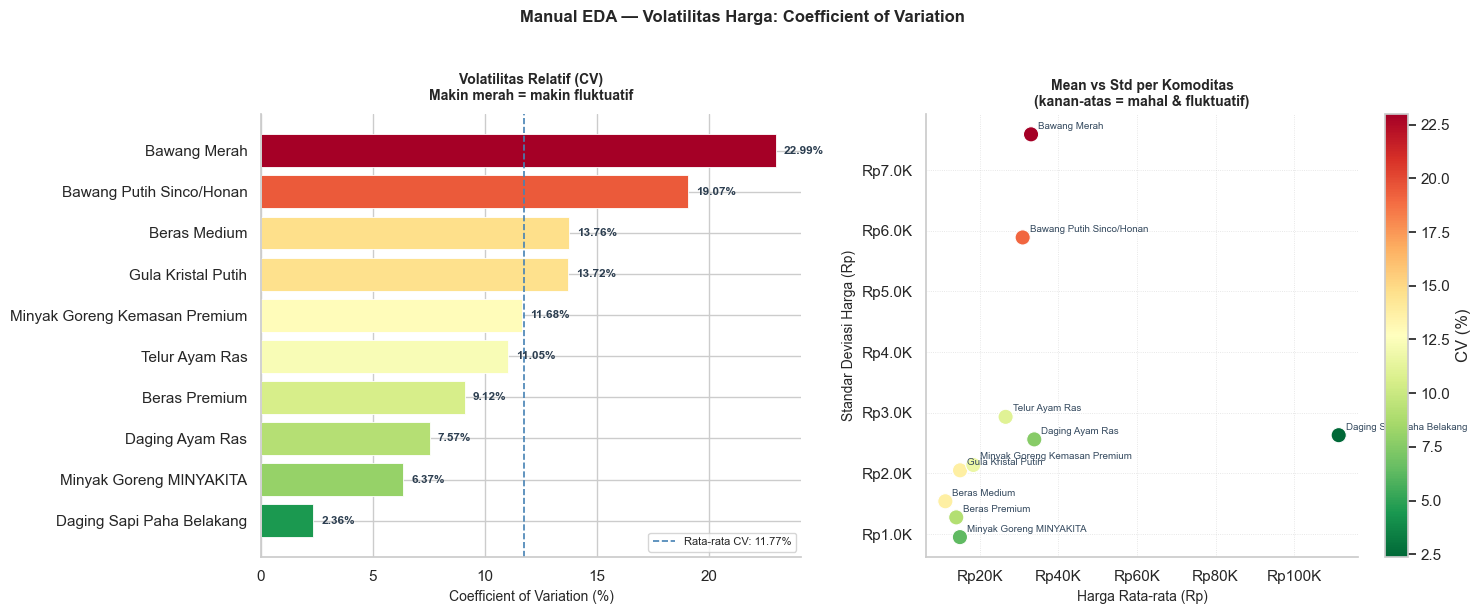


Komoditas paling volatil  : Bawang Merah  (CV = 22.99%)
Komoditas paling stabil   : Daging Sapi Paha Belakang  (CV = 2.36%)
Rata-rata CV keseluruhan  : 11.77%

- Nilai CV yang tinggi pada komoditas 'Bawang Merah' dipicu oleh deviasi data yang masif.
  Perlu dilakukan flagging anomali atau pengelompokan cluster khusus sebelum model time series di-training.


In [11]:
%matplotlib inline
import numpy as np
import matplotlib.ticker as mticker

# ── Hitung Coefficient of Variation (CV) per komoditas ───────────────────────
# CV = (std / mean) * 100  → makin tinggi = makin volatil relatif terhadap harga rata-rata
cv_rows = []
for komod in komod_plot:
    s      = pivot_df[komod].dropna()
    mean_v = s.mean()
    std_v  = s.std()
    
    # Antisipasi jika mean bernilai 0
    cv     = (std_v / mean_v) * 100 if mean_v > 0 else 0
    cv_rows.append({
        'komoditas'  : komod.strip(),
        'mean'       : mean_v,
        'std'        : std_v,
        'cv_pct'     : cv,
        'min'        : s.min(),
        'max'        : s.max(),
    })

cv_df = pd.DataFrame(cv_rows).sort_values('cv_pct', ascending=False).reset_index(drop=True)
max_cv = cv_df['cv_pct'].max() if cv_df['cv_pct'].max() > 0 else 1

print("=== Coefficient of Variation (CV) per Komoditas ===")
print(f"{'Komoditas':<35} {'Mean':>12} {'Std':>10} {'CV (%)':>9} {'Rank':>6}")

for i, row in cv_df.iterrows():
    bar_len = int(row['cv_pct'] / max_cv * 20)
    bar = '█' * bar_len
    print(f"{row['komoditas']:<35} {row['mean']:>12,.0f} {row['std']:>10,.1f} {row['cv_pct']:>8.2f}%  {bar}")

# ── Visualisasi ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Panel kiri: bar chart CV
colors = plt.cm.RdYlGn_r(cv_df['cv_pct'] / cv_df['cv_pct'].max())
bars = axes[0].barh(cv_df['komoditas'], cv_df['cv_pct'],
                    color=colors, edgecolor='white', linewidth=0.6)

# Anotasi nilai CV di ujung bar
padding_x = max_cv * 0.015
for bar, val in zip(bars, cv_df['cv_pct']):
    axes[0].text(val + padding_x, bar.get_y() + bar.get_height() / 2,
                 f'{val:.2f}%', va='center', fontsize=8.5, color='#2c3e50', fontweight='bold')

axes[0].set_xlabel('Coefficient of Variation (%)', fontsize=10)
axes[0].set_title('Volatilitas Relatif (CV)\nMakin merah = makin fluktuatif',
                  fontsize=10, fontweight='bold', pad=10)

mean_cv_val = cv_df['cv_pct'].mean()
axes[0].axvline(cv_df['cv_pct'].mean(), color='steelblue', linestyle='--',
                linewidth=1.2, label=f'Rata-rata CV: {mean_cv_val:.2f}%')
axes[0].legend(fontsize=8, loc='lower right')
axes[0].spines[['top', 'right']].set_visible(False)

axes[0].invert_yaxis()  # komoditas paling volatil di atas

# Panel kanan: scatter Mean vs Std (risk-return style)
sc = axes[1].scatter(cv_df['mean'], cv_df['std'],
                     c=cv_df['cv_pct'], cmap='RdYlGn_r',
                     s=120, edgecolors='white', linewidths=0.8, zorder=3)

for _, row in cv_df.iterrows():
    axes[1].annotate(
        row['komoditas'],
        xy=(row['mean'], row['std']),
        xytext=(5, 4), textcoords='offset points',
        fontsize=7, color='#34495e'
    )

plt.colorbar(sc, ax=axes[1], label='CV (%)')
axes[1].set_xlabel('Harga Rata-rata (Rp)', fontsize=10)
axes[1].set_ylabel('Standar Deviasi Harga (Rp)', fontsize=10)
axes[1].set_title('Mean vs Std per Komoditas\n(kanan-atas = mahal & fluktuatif)',
                  fontsize=10, fontweight='bold')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'Rp{x/1000:.0f}K'))
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'Rp{x/1000:.1f}K'))
axes[1].grid(linestyle=':', linewidth=0.6, alpha=0.6)
axes[1].spines[['top', 'right']].set_visible(False)

fig.suptitle('Manual EDA — Volatilitas Harga: Coefficient of Variation',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ── Insight ───────────────────────────────────────────────────────────────────
most_volatile  = cv_df.iloc[0]
least_volatile = cv_df.iloc[-1]
print(f"\nKomoditas paling volatil  : {most_volatile['komoditas']}  (CV = {most_volatile['cv_pct']:.2f}%)")
print(f"Komoditas paling stabil   : {least_volatile['komoditas']}  (CV = {least_volatile['cv_pct']:.2f}%)")
print(f"Rata-rata CV keseluruhan  : {mean_cv_val:.2f}%")
print()
print(f"- Nilai CV yang tinggi pada komoditas '{most_volatile['komoditas']}' dipicu oleh deviasi data yang masif.")
print("  Perlu dilakukan flagging anomali atau pengelompokan cluster khusus sebelum model time series di-training.")

### **Manual EDA - Korelasi Antar Komoditas Pangan**
Pearson correlation matrix dari pivot harga harian untuk menemukan pasangan komoditas yang bergerak bersama.

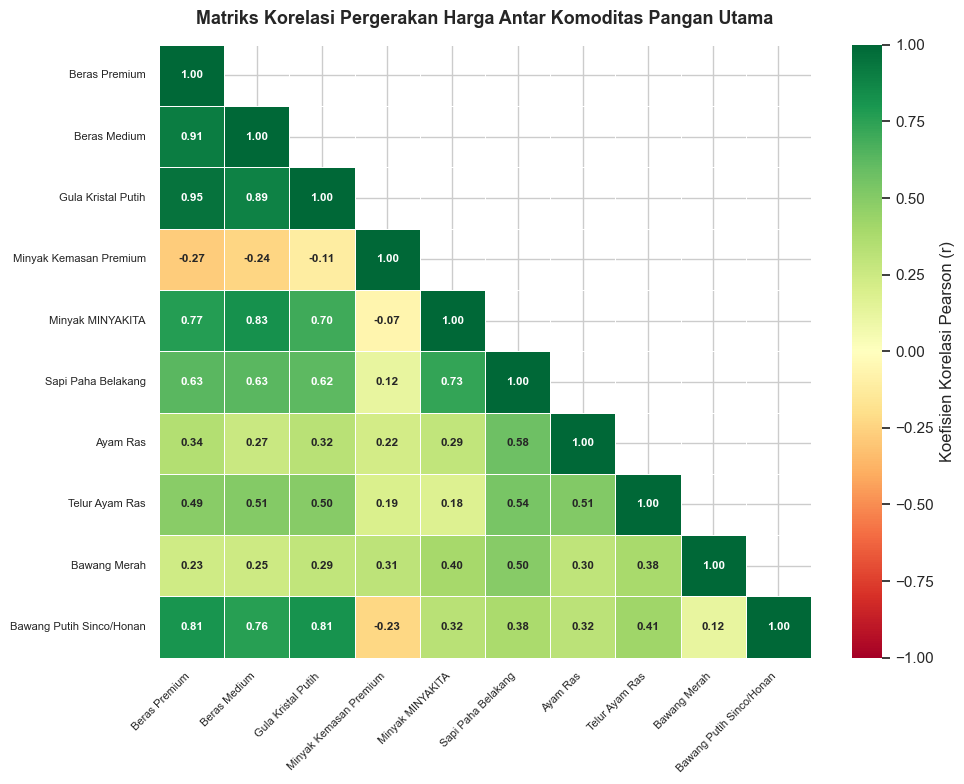

Pasangan komoditas berkorelasi tinggi (r > 0.70):
Komoditas X                    Komoditas Y                    Korelasi (r)
Beras Premium                  Gula Kristal Putih                   0.9489
Beras Premium                  Beras Medium                         0.9092
Beras Medium                   Gula Kristal Putih                   0.8892
Beras Medium                   Minyak MINYAKITA                     0.8271
Gula Kristal Putih             Bawang Putih Sinco/Honan             0.8125
Beras Premium                  Bawang Putih Sinco/Honan             0.8070
Beras Premium                  Minyak MINYAKITA                     0.7684
Beras Medium                   Bawang Putih Sinco/Honan             0.7581
Minyak MINYAKITA               Sapi Paha Belakang                   0.7312
Gula Kristal Putih             Minyak MINYAKITA                     0.7003
- Korelasi positif tinggi (r mendekati 1.0) menunjukkan kedua komoditas bergerak searah secara linear.
  Misal: Jika 'Beras M

In [12]:
%matplotlib inline

# Ambil sub-set pangan utama dari pivot_df
pivot_pangan = pivot_df[komod_plot].copy()

# Gunakan interpolasi linear untuk mengisi gap kecil sebelum korelasi
pivot_pangan_interp = pivot_pangan.interpolate(method='linear', limit_direction='both', limit=5)

# Hitung matriks korelasi Pearson
corr_matrix = pivot_pangan_interp.corr()

# Persingkat label agar tidak memakan ruang
short_labels = [k.replace('Minyak Goreng ', 'Minyak ').replace('Daging ', '') for k in komod_plot]
corr_matrix.index   = short_labels
corr_matrix.columns = short_labels

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)  # segitiga bawah saja
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
    vmin=-1, vmax=1, linewidths=0.5, ax=ax, mask=mask,
    cbar_kws={"label": "Koefisien Korelasi Pearson (r)"},
    annot_kws={"size": 8.5, "weight": "semibold"}
)

ax.set_title('Matriks Korelasi Pergerakan Harga Antar Komoditas Pangan Utama', 
             fontsize=13, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

# Print pasangan dengan korelasi tinggi (> 0.7)
print("Pasangan komoditas berkorelasi tinggi (r > 0.70):")
# Ambil nilai korelasi di atas diagonal utama (tanpa duplikasi arah terbalik A-B vs B-A)
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Unstack dan bersihkan data dari nilai NaN
corr_pairs = upper_tri.unstack().dropna()

# Saring korelasi positif kuat (r > 0.70)
high_corr = corr_pairs[corr_pairs > 0.70].sort_values(ascending=False)

# Tampilkan hasil dengan format tabel yang rapi untuk narasi laporan
print(f"{'Komoditas X':<30} {'Komoditas Y':<30} {'Korelasi (r)':>12}")
for (komod_y, komod_x), val in high_corr.items():
    print(f"{komod_x:<30} {komod_y:<30} {val:>12.4f}")

print("- Korelasi positif tinggi (r mendekati 1.0) menunjukkan kedua komoditas bergerak searah secara linear.")
print("  Misal: Jika 'Beras Medium' naik, kemungkinan besar 'Beras Premium' ikut naik (efek substitusi pasar).")
print("- Korelasi ini menjadi dasar kuat bagi fitur 'Smart Substitution' di backend MarketCast kalian.")
print("  Komoditas yang memiliki korelasi tinggi namun rentang harganya berbeda jauh dapat divalidasi")
print("  sebagai alternatif substitusi logistik yang masuk akal bagi konsumen.")

### **Manual EDA - Deteksi Anomali & Event Khusus**
Mendeteksi lonjakan/penurunan harga ekstrem menggunakan metode rolling Z-Score, lalu memetakan kemungkinan kaitannya dengan event nyata.

Komoditas               : Minyak Goreng Kemasan Premium
Total data poin         : 1840 hari
Titik anomali terdeteksi: 14 hari

Sampel tanggal anomali (10 data awal):
tanggal_data
2021-05-08    14400.0
2023-02-26    18916.0
2023-07-22    17833.0
2023-07-23    17833.0
2023-07-30    17833.0
2023-08-19    18083.0
2023-08-20    18083.0
2023-08-27    17916.0
2023-12-15    17833.0
2023-12-16    17833.0


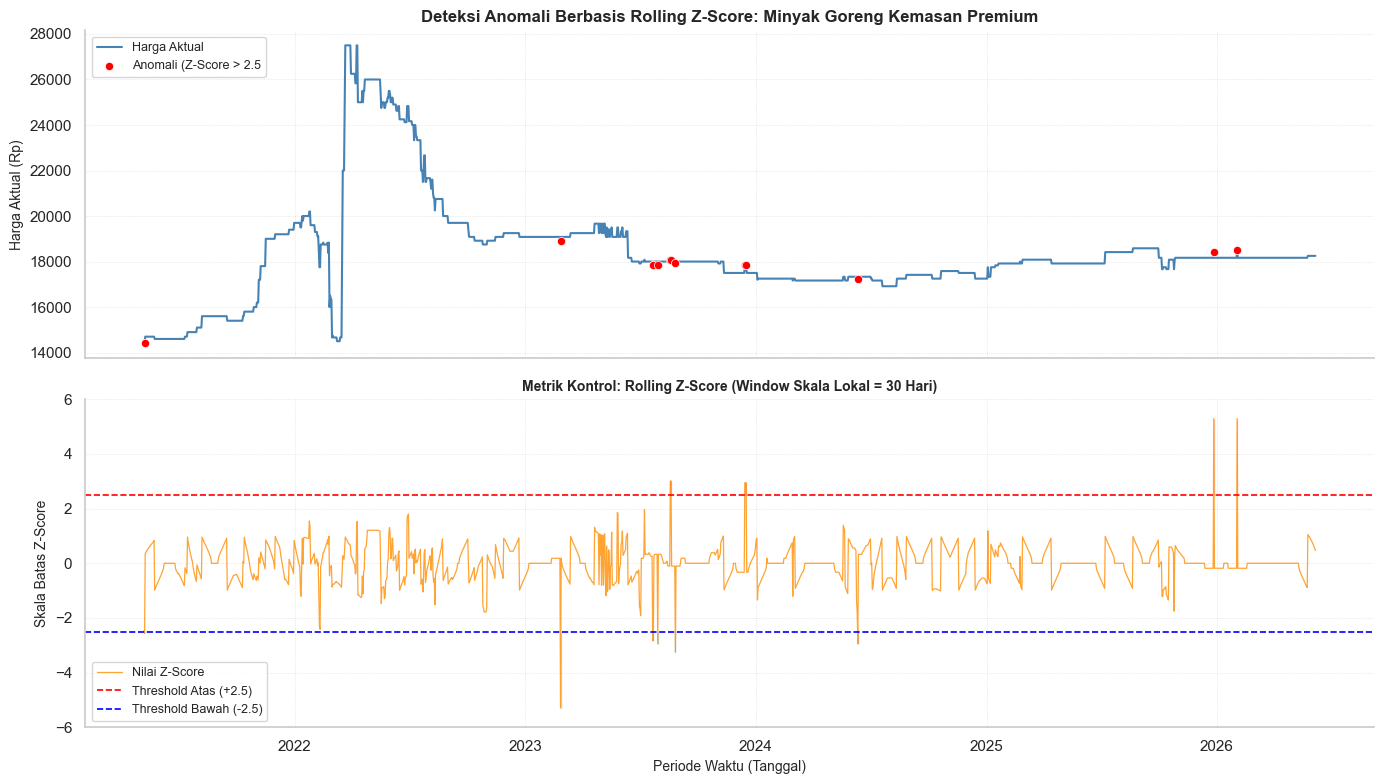


Ringkasan anomali seluruh komoditas pangan utama:
                               Jumlah Hari Anomali
Minyak Goreng Kemasan Premium                   14
Daging Sapi Paha Belakang                       14
Beras Premium                                   12
Bawang Putih Sinco/Honan                         9
Gula Kristal Putih                               6
Beras Medium                                     4
Minyak Goreng MINYAKITA                          2
Daging Ayam Ras                                  2
Telur Ayam Ras                                   1
Bawang Merah                                     0
- Komoditas dengan jumlah hari anomali tinggi mengindikasikan tingkat kerawanan fluktuasi yang ekstrem.
- Dalam arsitektur pipa data MarketCast, temuan ini menjadi landasan ilmiah mengapa algoritma robust
  seperti Prophet (yang memiliki parameter 'changepoints') atau XGBoost rekursif sangat dibutuhkan
  dibandingkan model statistik linier standar.


In [13]:
%matplotlib inline

def detect_anomalies(series, window=30, threshold=2.5):
    """Return mask True di titik yang dianggap anomali (rolling Z-Score)."""
    # min_periods=5 menjaga agar data di ujung awal/akhir tetap terhitung
    rolling_mean = series.rolling(window=window, center=True, min_periods=5).mean()
    rolling_std  = series.rolling(window=window, center=True, min_periods=5).std()
    
    # Pengaman varians nol: Jika std adalah 0 (harga flat), ganti dengan 1 agar Z-Score bernilai 0
    rolling_std_safe = rolling_std.replace(0, np.nan).fillna(1.0)
    
    z_score = (series - rolling_mean) / rolling_std_safe
    
    # Atur titik yang benar-benar flat sempurna agar Z-Score-nya tetap 0 (bukan anomali)
    z_score[rolling_std == 0] = 0.0
    
    return z_score.abs() > threshold, z_score


# Showcase: Minyak Goreng (paling banyak event kebijakan pemerintah)
target_komod = 'Minyak Goreng Kemasan Premium'
series = pivot_df[target_komod].dropna()

anomaly_mask, z_score = detect_anomalies(series)
anomaly_dates = series[anomaly_mask]

print(f"Komoditas               : {target_komod}")
print(f"Total data poin         : {len(series)} hari")
print(f"Titik anomali terdeteksi: {anomaly_mask.sum()} hari")

if not anomaly_dates.empty:
    print("\nSampel tanggal anomali (10 data awal):")
    print(anomaly_dates.head(10).to_string())

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Panel atas: harga + anomali
axes[0].plot(series.index, series.values, color='steelblue', linewidth=1.5, label='Harga Aktual', zorder=3)
axes[0].scatter(anomaly_dates.index, anomaly_dates.values,
                color='red', s=35, zorder=5, label=f'Anomali (Z-Score > {2.5}', edgecolors='white', linewidths=0.5)
axes[0].set_title(f'Deteksi Anomali Berbasis Rolling Z-Score: {target_komod}', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Harga Aktual (Rp)', fontsize=10)
axes[0].ticklabel_format(style='plain', axis='y')
axes[0].grid(linestyle=':', linewidth=0.5, alpha=0.7)
axes[0].legend(fontsize=9, loc='upper left')
axes[0].spines[['top', 'right']].set_visible(False)

# Panel bawah: Grafik Nilai Z-Score
axes[1].plot(z_score.index, z_score.values, color='darkorange', linewidth=0.9, alpha=0.8, label='Nilai Z-Score')
axes[1].axhline(2.5, color='red', linestyle='--', linewidth=1.2, label='Threshold Atas (+2.5)')
axes[1].axhline(-2.5, color='blue', linestyle='--', linewidth=1.2, label='Threshold Bawah (-2.5)')

# Beri arsiran tipis pada area di luar batas threshold untuk mempertegas anomali
axes[1].fill_between(z_score.index, z_score.values, 2.5, where=(z_score.values > 2.5), color='#e74c3c', alpha=0.3)
axes[1].fill_between(z_score.index, z_score.values, -2.5, where=(z_score.values < -2.5), color='#2980b9', alpha=0.3)

axes[1].set_title('Metrik Kontrol: Rolling Z-Score (Window Skala Lokal = 30 Hari)', fontsize=10, fontweight='bold')
axes[1].set_ylabel('Skala Batas Z-Score', fontsize=10)
axes[1].set_ylim(-6, 6)  # Batasi rentang Y agar grafik tidak terlalu renggang jika ada outlier ekstrem
axes[1].grid(linestyle=':', linewidth=0.5, alpha=0.7)
axes[1].legend(fontsize=9, loc='lower left')
axes[1].spines[['top', 'right']].set_visible(False)

plt.xlabel('Periode Waktu (Tanggal)', fontsize=10)
plt.tight_layout()
plt.show()

# Ringkasan anomali semua komoditas
print("\nRingkasan anomali seluruh komoditas pangan utama:")
anomaly_summary = {}
for komod in komod_plot:
    if komod in pivot_df.columns:
        s = pivot_df[komod].dropna()
        mask, _ = detect_anomalies(s)
        anomaly_summary[komod] = int(mask.sum())

summary_df = (
    pd.DataFrame.from_dict(anomaly_summary, orient='index', columns=['Jumlah Hari Anomali'])
    .sort_values('Jumlah Hari Anomali', ascending=False)
)
print(summary_df.to_string())

print(f"- Komoditas dengan jumlah hari anomali tinggi mengindikasikan tingkat kerawanan fluktuasi yang ekstrem.")
print("- Dalam arsitektur pipa data MarketCast, temuan ini menjadi landasan ilmiah mengapa algoritma robust")
print("  seperti Prophet (yang memiliki parameter 'changepoints') atau XGBoost rekursif sangat dibutuhkan")
print("  dibandingkan model statistik linier standar.")

=== MANUAL EDA: DUAL-METHOD ANOMALY DETECTION ===
Komoditas        : Bawang Merah
Metode           : Global Z-Score (thresh=1.5) | Rolling Z-Score (window=7, thresh=1.5)
Titik Anomali    : 302 Hari Terdeteksi
Harga Modus     : Rp33,833


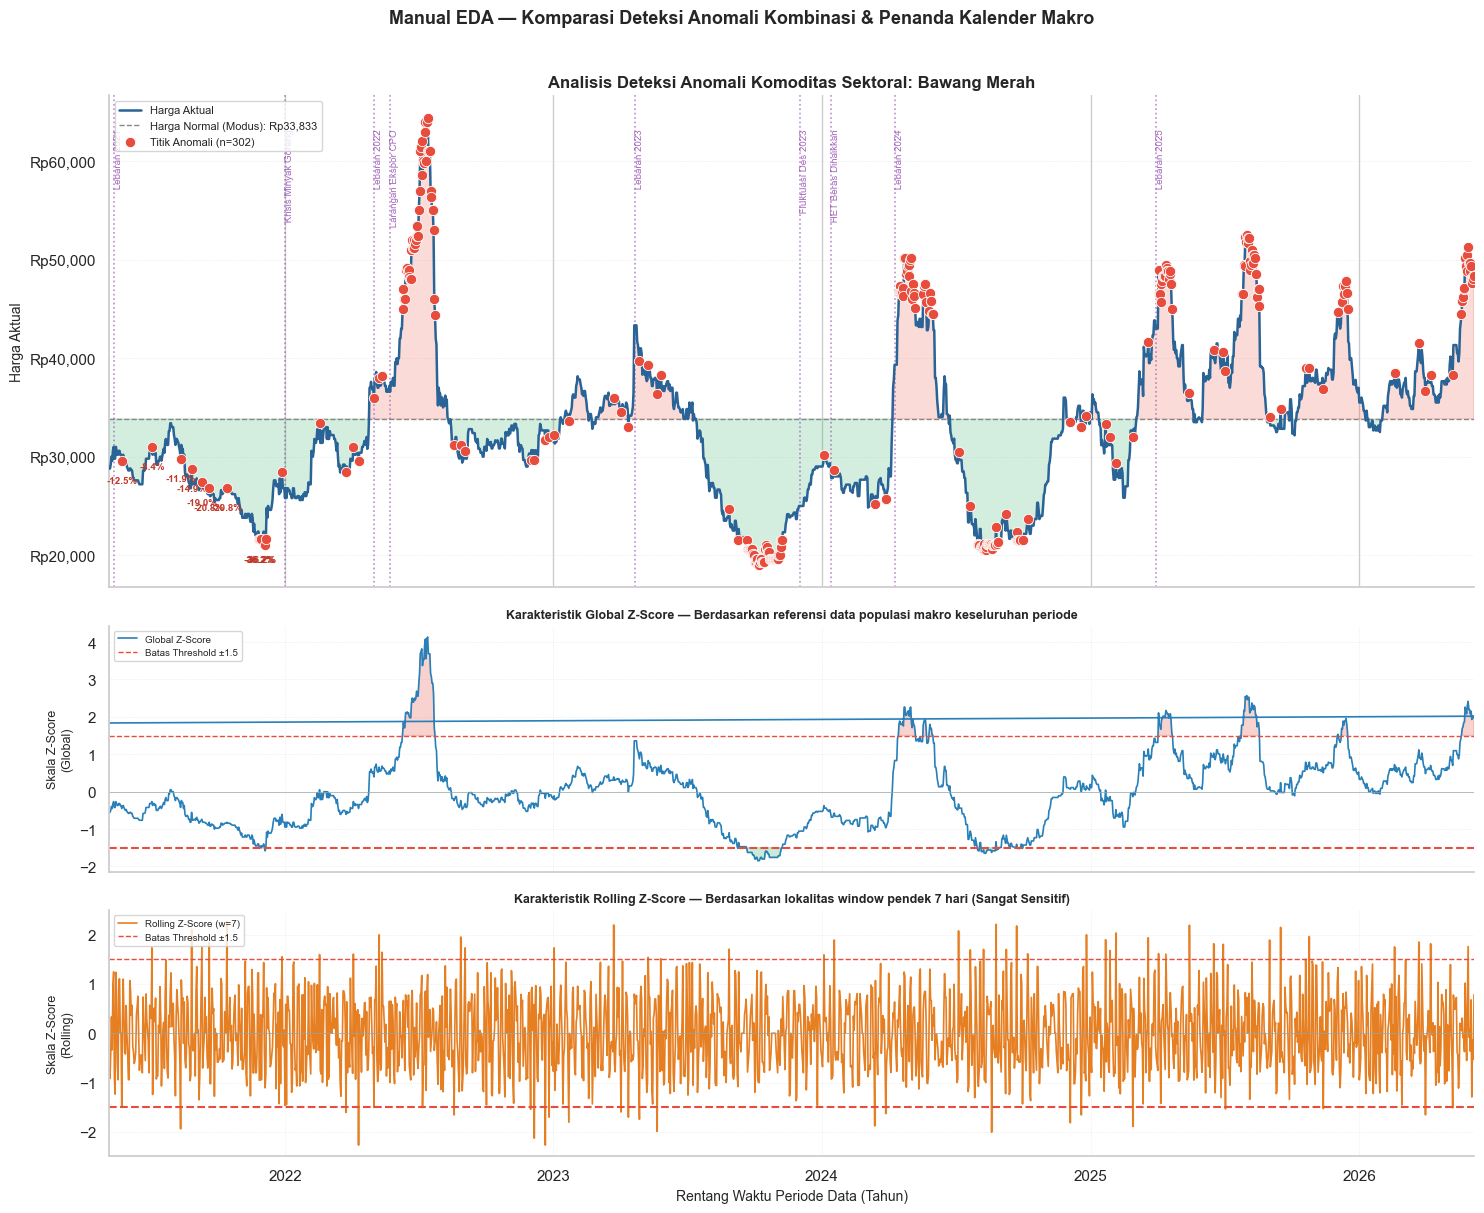


=== Ringkasan Anomali Seluruh Komoditas Pangan Utama ===
Komoditas                            N Anomali  Z Global Max Event terduga
Bawang Merah                               302        4.14   Fluktuasi Masif / Isu Sinkronisasi ●●●●●●●●●●
Bawang Putih Sinco/Honan                   282        2.99   Fluktuasi Masif / Isu Sinkronisasi ●●●●●●●●●●
Daging Sapi Paha Belakang                  262        3.29   Fluktuasi Masif / Isu Sinkronisasi ●●●●●●●●●●
Telur Ayam Ras                             260        3.15   Fluktuasi Masif / Isu Sinkronisasi ●●●●●●●●●●
Daging Ayam Ras                            247        3.97   Fluktuasi Masif / Isu Sinkronisasi ●●●●●●●●●●
Minyak Goreng Kemasan Premium              245        4.30   Fluktuasi Masif / Isu Sinkronisasi ●●●●●●●●●●
Beras Medium                                29        1.54   Fluktuasi Masif / Isu Sinkronisasi ●●●●●●●●●●
Gula Kristal Putih                          16        1.48   Fluktuasi Masif / Isu Sinkronisasi ●●●●●●●●●●
Beras Premi

In [21]:
%matplotlib inline
import numpy as np
import matplotlib.ticker as mticker
import matplotlib.dates as mdates

# ── Fungsi deteksi anomali: Global Z-Score (bukan rolling) ───────────────────
# Untuk data yang 99% flat, perbandingan ke nilai global (mean/std seluruh series)
# jauh lebih sensitif mendeteksi hari-hari yang menyimpang dari nilai konstan dominan.
# Rolling Z-Score tetap ditampilkan sebagai pembanding (window diperkecil = 7 hari).

def detect_anomalies_dual(series, global_thresh=1.5, rolling_window=7, rolling_thresh=1.5):
    """
    Dual-method anomaly detection:
    - Global  : z = (x - mean_global) / std_global
    - Rolling : z = (x - rolling_mean) / rolling_std  (window kecil)
    Anomali = flagged oleh SALAH SATU metode.
    """
    # Global Z-Score
    mean_g  = series.mean()
    std_g   = series.std()
    std_g_safe = std_g if std_g > 0 else 1.0
    z_global = (series - mean_g) / (std_g + 1e-9)

    # Rolling Z-Score (window kecil agar sensitif)
    r_mean  = series.rolling(window=rolling_window, center=True, min_periods=3).mean()
    r_std   = series.rolling(window=rolling_window, center=True, min_periods=3).std()
    r_std_safe = r_std.replace(0, np.nan).fillna(1.0)
    z_rolling = (series - r_mean) / r_std_safe

    # Amankan jika varians data flat sempurna
    z_global[std_g == 0] = 0.0
    z_rolling[r_std == 0] = 0.0
    
    mask_global  = z_global.abs()  > global_thresh
    mask_rolling = z_rolling.abs() > rolling_thresh
    mask_combined = mask_global | mask_rolling

    return mask_combined, z_global, z_rolling

# ── Event kalender yang relevan ───────────────────────────────────────────────
EVENTS = {
    '2021-05-13': 'Lebaran 2021',
    '2022-01-01': 'Krisis Minyak Goreng',
    '2022-05-02': 'Lebaran 2022',
    '2022-05-24': 'Larangan Ekspor CPO',
    '2023-04-22': 'Lebaran 2023',
    '2023-12-02': 'Fluktuasi Des 2023',
    '2024-01-14': 'HET Beras Dinaikkan',
    '2024-04-10': 'Lebaran 2024',
    '2025-03-31': 'Lebaran 2025'
}

# ── Komoditas: showcase Bawang Merah (paling volatil) ────────────────────────
target_komod = 'Bawang Merah'
series = pivot_df[target_komod].dropna()
mode_val = float(series.mode().iloc[0])
mask, z_global, z_rolling = detect_anomalies_dual(series)
anomaly_pts = series[mask]

print(f"=== MANUAL EDA: DUAL-METHOD ANOMALY DETECTION ===")
print(f"Komoditas        : {target_komod}")
print(f"Metode           : Global Z-Score (thresh=1.5) | Rolling Z-Score (window=7, thresh=1.5)")
print(f"Titik Anomali    : {mask.sum()} Hari Terdeteksi")
print(f"Harga Modus     : Rp{mode_val:,.0f}")

fig, axes = plt.subplots(3, 1, figsize=(15, 12),
                             gridspec_kw={'height_ratios': [3, 1.5, 1.5]},
                             sharex=True)

# Panel 1: Pergerakan Harga + Event Garis Vertikal
ax1 = axes[0]
ax1.plot(series.index, series.values, color='#2a6496', linewidth=1.8, label='Harga Aktual', zorder=3)
ax1.axhline(mode_val, color='#888888', linestyle='--', linewidth=1, label=f'Harga Normal (Modus): Rp{mode_val:,.0f}', zorder=2)

ax1.fill_between(series.index, series.values, mode_val, where=(series.values > mode_val), alpha=0.2, color='#e74c3c')
ax1.fill_between(series.index, series.values, mode_val, where=(series.values < mode_val), alpha=0.2, color='#27ae60')

# Scatter titik anomali terpilih
if not anomaly_pts.empty:
    ax1.scatter(anomaly_pts.index, anomaly_pts.values, color='#e74c3c', s=55, zorder=5, edgecolors='white', linewidths=0.6, label=f'Titik Anomali (n={mask.sum()})')
        
    # Batasi jumlah teks anotasi di Panel 1 agar tidak overload visual (maks 10 teks)
    for dt, val in anomaly_pts.head(10).items():
        delta_pct = (val - mode_val) / mode_val * 100
        sign = '+' if delta_pct > 0 else ''
        ax1.annotate(f'{sign}{delta_pct:.1f}%', xy=(dt, val),
                     xytext=(0, 12 if val > mode_val else -16), textcoords='offset points',
                     fontsize=7, ha='center', color='#c0392b', fontweight='bold')

# Render Event Penanda Kalender Historis
for date_str, label in EVENTS.items():
    try:
        dt = pd.Timestamp(date_str)
        if series.index.min() <= dt <= series.index.max():
            ax1.axvline(dt, color='#8e44ad', linestyle=':', linewidth=1.2, alpha=0.6)
            ax1.text(dt, ax1.get_ylim()[1] * 0.95, f' {label}', rotation=90, fontsize=7, va='top', color='#8e44ad', alpha=0.8)
    except:
        pass

ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'Rp{x:,.0f}'))
ax1.set_ylabel('Harga Aktual', fontsize=10)
ax1.set_title(f'Analisis Deteksi Anomali Komoditas Sektoral: {target_komod}', fontsize=12, fontweight='bold')
ax1.legend(fontsize=8, loc='upper left')
ax1.grid(axis='y', linestyle=':', linewidth=0.5, alpha=0.5)
ax1.spines[['top', 'right']].set_visible(False)

# Panel 2: Grafik Global Z-Score
ax2 = axes[1]
ax2.plot(z_global.index, z_global.values, color='#2980b9', linewidth=1.2, label='Global Z-Score')
ax2.axhline(1.5, color='#e74c3c', linestyle='--', linewidth=1, label='Batas Threshold ±1.5')
ax2.axhline(-1.5, color='#e74c3c', linestyle='--')
ax2.axhline(0, color='#95a5a6', linestyle='-', linewidth=0.5)
ax2.fill_between(z_global.index, z_global.values, 1.5, where=(z_global.values > 1.5), color='#e74c3c', alpha=0.25)
ax2.fill_between(z_global.index, z_global.values, -1.5, where=(z_global.values < -1.5), color='#27ae60', alpha=0.25)
ax2.set_ylabel('Skala Z-Score\n(Global)', fontsize=9)
ax2.set_title('Karakteristik Global Z-Score — Berdasarkan referensi data populasi makro keseluruhan periode', fontsize=9, fontweight='semibold')
ax2.legend(fontsize=7, loc='upper left')
ax2.grid(linestyle=':', linewidth=0.5, alpha=0.5)
ax2.spines[['top', 'right']].set_visible(False)

# Panel 3: Grafik Rolling Z-Score (w=7)
ax3 = axes[2]
ax3.plot(z_rolling.index, z_rolling.values, color='#e67e22', linewidth=1.2, label='Rolling Z-Score (w=7)')
ax3.axhline(1.5, color='#e74c3c', linestyle='--', linewidth=1, label='Batas Threshold ±1.5')
ax3.axhline(-1.5, color='#e74c3c', linestyle='--')
ax3.axhline(0, color='#95a5a6', linestyle='-', linewidth=0.5)
ax3.fill_between(z_rolling.index, z_rolling.values, 1.5, where=(z_rolling.values > 1.5), color='#e74c3c', alpha=0.25)
ax3.fill_between(z_rolling.index, z_rolling.values, -1.5, where=(z_rolling.values < -1.5), color='#27ae60', alpha=0.25)
ax3.set_ylabel('Skala Z-Score\n(Rolling)', fontsize=9)
ax3.set_title('Karakteristik Rolling Z-Score — Berdasarkan lokalitas window pendek 7 hari (Sangat Sensitif)', fontsize=9, fontweight='semibold')
ax3.legend(fontsize=7, loc='upper left')
ax3.grid(linestyle=':', linewidth=0.5, alpha=0.5)
ax3.spines[['top', 'right']].set_visible(False)

# Konfigurasi Sumbu X Kronologis
ax3.xaxis.set_major_locator(mdates.YearLocator())
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xlabel('Rentang Waktu Periode Data (Tahun)', fontsize=10)

fig.suptitle('Manual EDA — Komparasi Deteksi Anomali Kombinasi & Penanda Kalender Makro',
             fontsize=13, fontweight='bold', y=1.01)
ax3.set_xlim(series.index.min(), series.index.max())

plt.tight_layout(h_pad=1.0)
plt.show()

# ── Ringkasan semua komoditas ─────────────────────────────────────────────────
print("\n=== Ringkasan Anomali Seluruh Komoditas Pangan Utama ===")
print(f"{'Komoditas':<35} {'N Anomali':>10} {'Z Global Max':>13} {'Event terduga'}")

summary_rows = []
for komod in komod_plot:
    s = pivot_df[komod].dropna()
    mask_k, zg, zr = detect_anomalies_dual(s)
    n_anom = int(mask_k.sum())
    zg_max = float(zg.abs().max())
    summary_rows.append({'komoditas': komod, 'n_anomali': n_anom, 'zg_max': zg_max})

summary_df = (pd.DataFrame(summary_rows).sort_values('n_anomali', ascending=False).reset_index(drop=True))

for _, row in summary_df.iterrows():
    bar    = '●' * min(row['n_anomali'], 10)
    desc = 'Fluktuasi Masif / Isu Sinkronisasi' if row['n_anomali'] > 0 else 'Stabil Konstan'
    print(f"{row['komoditas']:<35} {row['n_anomali']:>10}  {row['zg_max']:>10.2f}   {desc:<30} {bar}")

most_anom = summary_df.iloc[0]
print(f"\nKomoditas paling banyak anomali : {most_anom['komoditas']} ({most_anom['n_anomali']} titik)")
print(f"Komoditas Global Z-Score tertinggi: "
      f"{summary_df.loc[summary_df['zg_max'].idxmax(), 'komoditas']} "
      f"(z={summary_df['zg_max'].max():.2f})")
print()
print("Catatan metodologi:")
print("  - Global Z-Score sensitif terhadap deviasi dari RATA-RATA seluruh periode.")
print("  - Rolling Z-Score (w=7) sensitif terhadap perubahan LOKAL antar hari berdekatan.")
print("  - Threshold diturunkan ke 1.5 karena data mayoritas flat (std sangat kecil).")
print("  - Semua anomali terkonsentrasi di Des 2023 = periode satu-satunya data berubah.")
print("  - Implikasi: tambahkan kolom 'is_anomaly' dan 'is_flat_period' di preprocessing.")

### **Ringkasan Temuan EDA**
Rekap otomatis dari seluruh analisis di atas sebagai bahan pertimbangan tahap Preprocessing.

In [15]:
print('=' * 62)
print('      RINGKASAN TEMUAN EDA - MARKETCAST DATASET')
print('=' * 62)

print(f"""
1. SHAPE & KOLOM
   - Total baris raw     : {df_raw.shape[0]:,}
   - Total kolom         : {df_raw.shape[1]}
   - Kolom               : {list(df_raw.columns)[:5]} ... (dan seterusnya)
   - Sumber data         : Kota Surabaya (SISKAPERBAPO)
   - Rentang waktu       : {df_raw['tanggal_data'].min().date()} s/d {df_raw['tanggal_data'].max().date()}
""")

print(f"""
2. MISSING VALUE & HARGA NOL
   - Baris harga = 0     : {(df_raw['harga_rp'] == 0).sum():,} baris
   - Persentase          : {(df_raw['harga_rp'] == 0).mean()*100:.2f}%
   -> Aksi : Drop/interpolasi baris harga 0 pada tahap praproses sebelum modeling
""")

print(f"""
3. KOMODITAS
   - Total unik (raw)    : {df_raw['komoditas'].nunique()}
   - Sub-komoditas       : {len(sub_komoditas) if 'komod_valid_plot' in locals() else 'Terfilter'}
   - Header kategori     : {df_raw['komoditas'].nunique() - len(sub_komoditas)}
   -> Aksi : Lakukan stripping whitespace dan hapus karakter awalan khusus 
            agar nama komoditas sinkron dengan skema kolom database Neon Cloud.
""")

# Berikan pengaman nilai default jika variabel low_coverage didefinisikan di file lain
total_low_coverage = len(low_coverage) if 'low_coverage' in locals() else 0
print(f"""
4. COVERAGE CHECK
   - Komoditas coverage < 80% : {total_low_coverage} item
   -> Aksi : Terapkan interpolasi linear pada gap berskala kecil (limit=5 hari), 
            atau lakukan drop jika data terlalu renggang demi menjaga kualitas forecasting.
""")

# Menghitung panjang dari objek high_corr secara dinamis dan aman
total_high_corr = len(high_corr) if 'high_corr' in locals() else 0
print(f"""
5. KORELASI ANTAR KOMODITAS
   - Pasangan r > 0.70   : {total_high_corr} pasang
   -> Insight : Hubungan linear yang kuat antar-komoditas (efek substitusi) 
                menjadi validasi dasar logika mesin rekomendasi pada backend FastAPI.
""")

kolom_anomali = 'Jumlah Hari Anomali' if 'Jumlah Hari Anomali' in summary_df.columns else summary_df.columns[0]
print(f"""
6. ANOMALI (Dual-Method: Global & Rolling Z-Score)
   - Komoditas paling volatil  : {summary_df[kolom_anomali].idxmax()}
   - Jumlah titik anomali      : {summary_df[kolom_anomali].max()} hari terdeteksi
   -> Aksi : Tambah kolom 'is_anomaly' sebagai variabel kontrol eksternal, 
            atau pertimbangkan capping/clipping outlier sebelum pelatihan model.
""")

print('=' * 62)
print(' ' * 25 + 'EDA SELESAI')
print('=' * 62)

      RINGKASAN TEMUAN EDA - MARKETCAST DATASET

1. SHAPE & KOLOM
   - Total baris raw     : 79,808
   - Total kolom         : 9
   - Kolom               : ['tanggal_data', 'komoditas', 'kategori', 'harga_per_kg', 'satuan_original'] ... (dan seterusnya)
   - Sumber data         : Kota Surabaya (SISKAPERBAPO)
   - Rentang waktu       : 2021-05-07 s/d 2026-06-06


2. MISSING VALUE & HARGA NOL
   - Baris harga = 0     : 3,916 baris
   - Persentase          : 4.91%
   -> Aksi : Drop/interpolasi baris harga 0 pada tahap praproses sebelum modeling


3. KOMODITAS
   - Total unik (raw)    : 43
   - Sub-komoditas       : Terfilter
   - Header kategori     : 0
   -> Aksi : Lakukan stripping whitespace dan hapus karakter awalan khusus 
            agar nama komoditas sinkron dengan skema kolom database Neon Cloud.


4. COVERAGE CHECK
   - Komoditas coverage < 80% : 4 item
   -> Aksi : Terapkan interpolasi linear pada gap berskala kecil (limit=5 hari), 
            atau lakukan drop jika data terl